In [1]:
# VSCode.Cell - Load All Results

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Load training results from 5 experiments
results_dir = Path('results')

df1 = pd.read_csv(results_dir / 'fourway_1x1_penetration0.5_turn/train_results.csv')
df2 = pd.read_csv(results_dir / 'fourway_1x1_penetration0.5_turn_adam/train_results.csv')
df3 = pd.read_csv(results_dir / 'fourway_1x1_penetration0.5_turn_adam_ppo/train_results.csv')
df4 = pd.read_csv(results_dir / 'fourway_1x1_penetration0.5_turn_adam_ppo_26.11/train_results.csv')
df5 = pd.read_csv(results_dir / 'fourway_1x1_penetration0.5_turn_adam_ppo_27.11/train_results.csv')

# Load baseline results
baseline_dir = Path('results/fourway_1x1_left_right_turn_baselines/eval_results')
baseline_files = sorted(baseline_dir.glob('*.csv'))

df6 = pd.read_csv(baseline_files[0]) if len(baseline_files) > 0 else None
df7 = pd.read_csv(baseline_files[1]) if len(baseline_files) > 1 else None
df8 = pd.read_csv(baseline_files[2]) if len(baseline_files) > 2 else None
df9 = pd.read_csv(baseline_files[3]) if len(baseline_files) > 3 else None

print("✓ Loaded training results:")
print(f"  df1: {len(df1)} steps - RMSProp + PG")
print(f"  df2: {len(df2)} steps - Adam + PG")
print(f"  df3: {len(df3)} steps - Adam + PPO (initial)")
print(f"  df4: {len(df4)} steps - Adam + PPO (26.11 tuning)")
print(f"  df5: {len(df5)} steps - Adam + PPO (27.11 tuning)")

print("\n✓ Loaded baseline results:")
for i, (df, file) in enumerate([(df6, baseline_files[0] if len(baseline_files) > 0 else None),
                                  (df7, baseline_files[1] if len(baseline_files) > 1 else None),
                                  (df8, baseline_files[2] if len(baseline_files) > 2 else None),
                                  (df9, baseline_files[3] if len(baseline_files) > 3 else None)], start=6):
    if df is not None:
        print(f"  df{i}: {len(df)} entries - {file.name}")
    else:
        print(f"  df{i}: Not found")

✓ Loaded training results:
  df1: 166 steps - RMSProp + PG
  df2: 166 steps - Adam + PG
  df3: 171 steps - Adam + PPO (initial)
  df4: 91 steps - Adam + PPO (26.11 tuning)
  df5: 201 steps - Adam + PPO (27.11 tuning)

✓ Loaded baseline results:
  df6: 3 entries - skip500_fixedtime_yellow3_flow700x700.csv
  df7: 3 entries - skip500_hpriority_flow700x700.csv
  df8: 3 entries - skip500_mpbest_yellow3_flow700x700.csv
  df9: 3 entries - skip500_vpriority_flow700x700.csv


In [2]:
# VSCode.Cell - Calculate Hourly Outflow

# Training experiments: convert outflow to hourly rate
# Assuming each rollout is at a specific horizon (e.g., 2000 steps = 1000 seconds with sim_step=0.5)
# outflow_hourly = (outflow / simulation_time_hours)

def calculate_hourly_outflow(df, horizon=2000, sim_step=0.5):
    """Convert outflow per rollout to vehicles per hour"""
    simulation_time_seconds = horizon * sim_step
    simulation_time_hours = simulation_time_seconds / 3600
    df['outflow_hourly'] = df['outflow'] / simulation_time_hours
    return df

# Apply to training results
df1 = calculate_hourly_outflow(df1.copy())
df2 = calculate_hourly_outflow(df2.copy())
df3 = calculate_hourly_outflow(df3.copy())
df4 = calculate_hourly_outflow(df4.copy())
df5 = calculate_hourly_outflow(df5.copy())

print("✓ Calculated hourly outflow for training experiments")

# Check if baseline results already have outflow_hourly or need calculation
for i, df in enumerate([df6, df7, df8, df9], start=6):
    if df is not None:
        if 'outflow_hourly' not in df.columns:
            if 'outflow' in df.columns:
                df = calculate_hourly_outflow(df.copy())
                globals()[f'df{i}'] = df
                print(f"  Calculated for df{i}")
            else:
                print(f"  ⚠️ df{i}: No outflow column found")
        else:
            print(f"  df{i}: Already has outflow_hourly")

✓ Calculated hourly outflow for training experiments
  df6: Already has outflow_hourly
  df7: Already has outflow_hourly
  df8: Already has outflow_hourly
  df9: Already has outflow_hourly


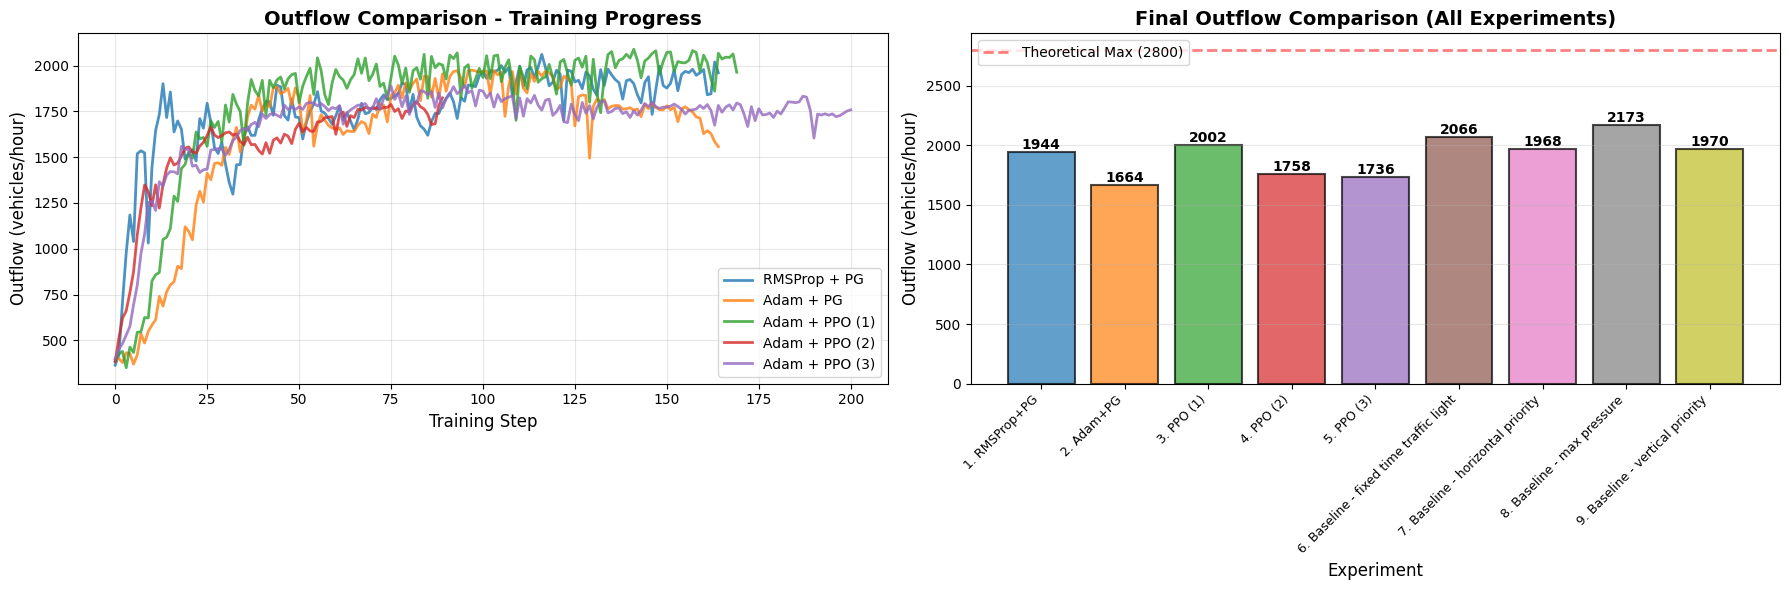


OUTFLOW STATISTICS (vehicles/hour)
1. RMSProp+PG                 :  1943.5 veh/hr
2. Adam+PG                    :  1664.4 veh/hr
3. PPO (1)                    :  2002.2 veh/hr
4. PPO (2)                    :  1758.4 veh/hr
5. PPO (3)                    :  1736.1 veh/hr
6. Baseline - fixed time traffic light:  2066.4 veh/hr
7. Baseline - horizontal priority:  1968.0 veh/hr
8. Baseline - max pressure    :  2173.2 veh/hr
9. Baseline - vertical priority:  1970.4 veh/hr


In [3]:
# VSCode.Cell - Comparison Plot: Outflow (Hourly)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Left plot: Training experiments (df1-df5) ---
ax1 = axes[0]

# Plot training curves
ax1.plot(df1['step'], df1['outflow_hourly'], label='RMSProp + PG', linewidth=2, alpha=0.8)
ax1.plot(df2['step'], df2['outflow_hourly'], label='Adam + PG', linewidth=2, alpha=0.8)
ax1.plot(df3['step'], df3['outflow_hourly'], label='Adam + PPO (1)', linewidth=2, alpha=0.8)
ax1.plot(df4['step'], df4['outflow_hourly'], label='Adam + PPO (2)', linewidth=2, alpha=0.8)
ax1.plot(df5['step'], df5['outflow_hourly'], label='Adam + PPO (3)', linewidth=2, alpha=0.8)

ax1.set_title('Outflow Comparison - Training Progress', fontsize=14, fontweight='bold')
ax1.set_xlabel('Training Step', fontsize=12)
ax1.set_ylabel('Outflow (vehicles/hour)', fontsize=12)
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# --- Right plot: Final performance comparison (all 9) ---
ax2 = axes[1]

# Get final values from training experiments (last 10 steps average)
final_values = []
labels = []
colors = []

# Training experiments
for i, (df, name, color) in enumerate([
    (df1, 'RMSProp+PG', 'C0'),
    (df2, 'Adam+PG', 'C1'),
    (df3, 'PPO (1)', 'C2'),
    (df4, 'PPO (2)', 'C3'),
    (df5, 'PPO (3)', 'C4')
], start=1):
    final_value = df['outflow_hourly'].iloc[-10:].mean()
    final_values.append(final_value)
    labels.append(f'{i}. {name}')
    colors.append(color)

# Baseline experiments
for i, (df, name, color) in enumerate([
    (df6, 'Baseline - fixed time traffic light', 'C5'),
    (df7, 'Baseline - horizontal priority', 'C6'),
    (df8, 'Baseline - max pressure', 'C7'),
    (df9, 'Baseline - vertical priority', 'C8')
], start=6):
    if df is not None and 'outflow_hourly' in df.columns:
        final_value = df['outflow_hourly'].mean()
        final_values.append(final_value)
        labels.append(f'{i}. {name}')
        colors.append(color)

# Create bar plot
x_pos = np.arange(len(labels))
bars = ax2.bar(x_pos, final_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, final_values)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.0f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_title('Final Outflow Comparison (All Experiments)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Experiment', fontsize=12)
ax2.set_ylabel('Outflow (vehicles/hour)', fontsize=12)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# Add horizontal line for theoretical maximum (if known)
# Theoretical max = flow_rate_h + flow_rate_v = (700 + 700) * 2 = 2800 veh/hr
ax2.axhline(y=2800, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Theoretical Max (2800)')
ax2.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*80)
print("OUTFLOW STATISTICS (vehicles/hour)")
print("="*80)
for label, value in zip(labels, final_values):
    print(f"{label:30s}: {value:7.1f} veh/hr")
print("="*80)

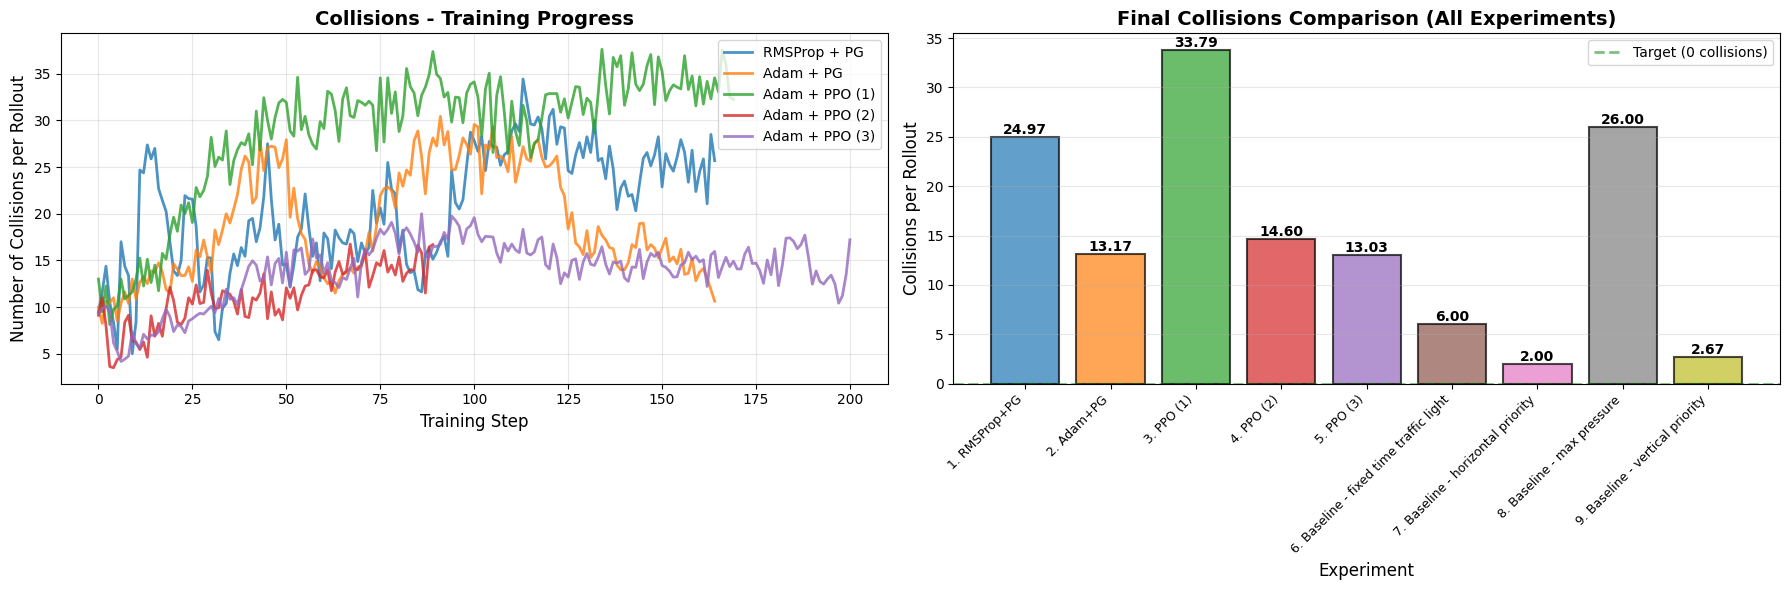


COLLISION STATISTICS (per rollout)
1. RMSProp+PG                 :   24.97 collisions
2. Adam+PG                    :   13.17 collisions
3. PPO (1)                    :   33.79 collisions
4. PPO (2)                    :   14.60 collisions
5. PPO (3)                    :   13.03 collisions
6. Baseline - fixed time traffic light:    6.00 collisions
7. Baseline - horizontal priority:    2.00 collisions
8. Baseline - max pressure    :   26.00 collisions
9. Baseline - vertical priority:    2.67 collisions


In [8]:
# VSCode.Cell - Comparison Plot: Collisions

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Left plot: Training experiments (df1-df5) ---
ax1 = axes[0]

# Plot training curves
ax1.plot(df1['step'], df1['collisions'], label='RMSProp + PG', linewidth=2, alpha=0.8)
ax1.plot(df2['step'], df2['collisions'], label='Adam + PG', linewidth=2, alpha=0.8)
ax1.plot(df3['step'], df3['collisions'], label='Adam + PPO (1)', linewidth=2, alpha=0.8)
ax1.plot(df4['step'], df4['collisions'], label='Adam + PPO (2)', linewidth=2, alpha=0.8)
ax1.plot(df5['step'], df5['collisions'], label='Adam + PPO (3)', linewidth=2, alpha=0.8)

ax1.set_title('Collisions - Training Progress', fontsize=14, fontweight='bold')
ax1.set_xlabel('Training Step', fontsize=12)
ax1.set_ylabel('Number of Collisions per Rollout', fontsize=12)
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)

# --- Right plot: Final performance comparison (all 9) ---
ax2 = axes[1]

# Get final values from training experiments (last 10 steps average)
final_collisions = []
labels = []
colors = []

# Training experiments
for i, (df, name, color) in enumerate([
    (df1, 'RMSProp+PG', 'C0'),
    (df2, 'Adam+PG', 'C1'),
    (df3, 'PPO (1)', 'C2'),
    (df4, 'PPO (2)', 'C3'),
    (df5, 'PPO (3)', 'C4')
], start=1):
    final_value = df['collisions'].iloc[-10:].mean()
    final_collisions.append(final_value)
    labels.append(f'{i}. {name}')
    colors.append(color)

# Baseline experiments
for i, (df, name, color) in enumerate([
    (df6, 'Baseline - fixed time traffic light', 'C5'),
    (df7, 'Baseline - horizontal priority', 'C6'),
    (df8, 'Baseline - max pressure', 'C7'),
    (df9, 'Baseline - vertical priority', 'C8')
], start=6):
    if df is not None and 'collisions' in df.columns:
        final_value = df['collisions'].mean()
        final_collisions.append(final_value)
        labels.append(f'{i}. {name}')
        colors.append(color)

# Create bar plot
x_pos = np.arange(len(labels))
bars = ax2.bar(x_pos, final_collisions, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, final_collisions)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_title('Final Collisions Comparison (All Experiments)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Experiment', fontsize=12)
ax2.set_ylabel('Collisions per Rollout', fontsize=12)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# Add target line (zero collisions)
ax2.axhline(y=0, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Target (0 collisions)')
ax2.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*80)
print("COLLISION STATISTICS (per rollout)")
print("="*80)
for label, value in zip(labels, final_collisions):
    print(f"{label:30s}: {value:7.2f} collisions")
print("="*80)

In [5]:
# VSCode.Cell - Combined Comparison Table

import pandas as pd

# Collect all metrics for comparison
comparison_data = []

# Training experiments
for i, (df, name) in enumerate([
    (df1, 'RMSProp + PG'),
    (df2, 'Adam + PG'),
    (df3, 'Adam + PPO (initial)'),
    (df4, 'Adam + PPO (26.11)'),
    (df5, 'Adam + PPO (27.11)')
], start=1):
    row = {
        'Experiment': f'{i}. {name}',
        'Type': 'Training',
        'Outflow (veh/hr)': df['outflow_hourly'].iloc[-10:].mean(),
        'Collisions': df['collisions'].iloc[-10:].mean(),
        'Speed (m/s)': df['speed'].iloc[-10:].mean() if 'speed' in df.columns else None,
        'Speed RL (m/s)': df['speed_rl'].iloc[-10:].mean() if 'speed_rl' in df.columns else None,
    }
    
    # Add reward if available
    if 'global_reward_mean' in df.columns:
        row['Reward'] = df['global_reward_mean'].iloc[-10:].mean()
    elif 'reward_mean' in df.columns:
        row['Reward'] = df['reward_mean'].iloc[-10:].mean()
    
    comparison_data.append(row)

# Baseline experiments
for i, (df, file) in enumerate([(df6, baseline_files[0] if len(baseline_files) > 0 else None),
                                 (df7, baseline_files[1] if len(baseline_files) > 1 else None),
                                 (df8, baseline_files[2] if len(baseline_files) > 2 else None),
                                 (df9, baseline_files[3] if len(baseline_files) > 3 else None)], start=6):
    if df is not None:
        baseline_name = file.stem.replace('eval_results_', '').replace('_', ' ').title()
        row = {
            'Experiment': f'{i}. {baseline_name}',
            'Type': 'Baseline',
            'Outflow (veh/hr)': df['outflow_hourly'].mean() if 'outflow_hourly' in df.columns else None,
            'Collisions': df['collisions'].mean() if 'collisions' in df.columns else None,
            'Speed (m/s)': df['speed'].mean() if 'speed' in df.columns else None,
            'Speed RL (m/s)': df['speed_rl'].mean() if 'speed_rl' in df.columns else None,
        }
        
        if 'reward_mean' in df.columns:
            row['Reward'] = df['reward_mean'].mean()
        
        comparison_data.append(row)

# Create comparison DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Display formatted table
print("\n" + "="*100)
print("COMPREHENSIVE COMPARISON - ALL EXPERIMENTS")
print("="*100)
print(comparison_df.to_string(index=False, float_format=lambda x: f'{x:.2f}' if pd.notnull(x) else 'N/A'))
print("="*100)

# Find best performers
print("\n" + "="*100)
print("BEST PERFORMERS")
print("="*100)
best_outflow = comparison_df.loc[comparison_df['Outflow (veh/hr)'].idxmax()]
print(f"✓ Highest Outflow: {best_outflow['Experiment']} ({best_outflow['Outflow (veh/hr)']:.1f} veh/hr)")

best_collisions = comparison_df.loc[comparison_df['Collisions'].idxmin()]
print(f"✓ Lowest Collisions: {best_collisions['Experiment']} ({best_collisions['Collisions']:.2f} collisions)")

if 'Speed (m/s)' in comparison_df.columns and comparison_df['Speed (m/s)'].notna().any():
    best_speed = comparison_df.loc[comparison_df['Speed (m/s)'].idxmax()]
    print(f"✓ Highest Speed: {best_speed['Experiment']} ({best_speed['Speed (m/s)']:.2f} m/s)")

if 'Reward' in comparison_df.columns and comparison_df['Reward'].notna().any():
    best_reward = comparison_df.loc[comparison_df['Reward'].idxmax()]
    print(f"✓ Highest Reward: {best_reward['Experiment']} ({best_reward['Reward']:.2f})")
print("="*100)

# Export to CSV
comparison_df.to_csv('results/experiment_comparison.csv', index=False)
print("\n✓ Comparison table saved to: results/experiment_comparison.csv")


COMPREHENSIVE COMPARISON - ALL EXPERIMENTS
                              Experiment     Type  Outflow (veh/hr)  Collisions  Speed (m/s)  Speed RL (m/s)  Reward
                         1. RMSProp + PG Training           1943.55       24.97         2.95            2.88    0.00
                            2. Adam + PG Training           1664.43       13.17         2.37            2.30    0.00
                 3. Adam + PPO (initial) Training           2002.22       33.79         2.62            2.60    0.19
                   4. Adam + PPO (26.11) Training           1758.38       14.60         4.46            4.13    0.17
                   5. Adam + PPO (27.11) Training           1736.07       13.03         3.70            3.45    0.18
6. Skip500 Fixedtime Yellow3 Flow700X700 Baseline           2066.40        6.00         2.35             NaN     NaN
        7. Skip500 Hpriority Flow700X700 Baseline           1968.00        2.00         2.23             NaN     NaN
   8. Skip500 Mpbest

/home/thickhoctin/miniconda3/envs/thesis_env/lib/python3.10/site-packages/pandas/core/indexes/base.py:7900: RuntimeWarning: invalid value encountered in cast
  values = values.astype(str)


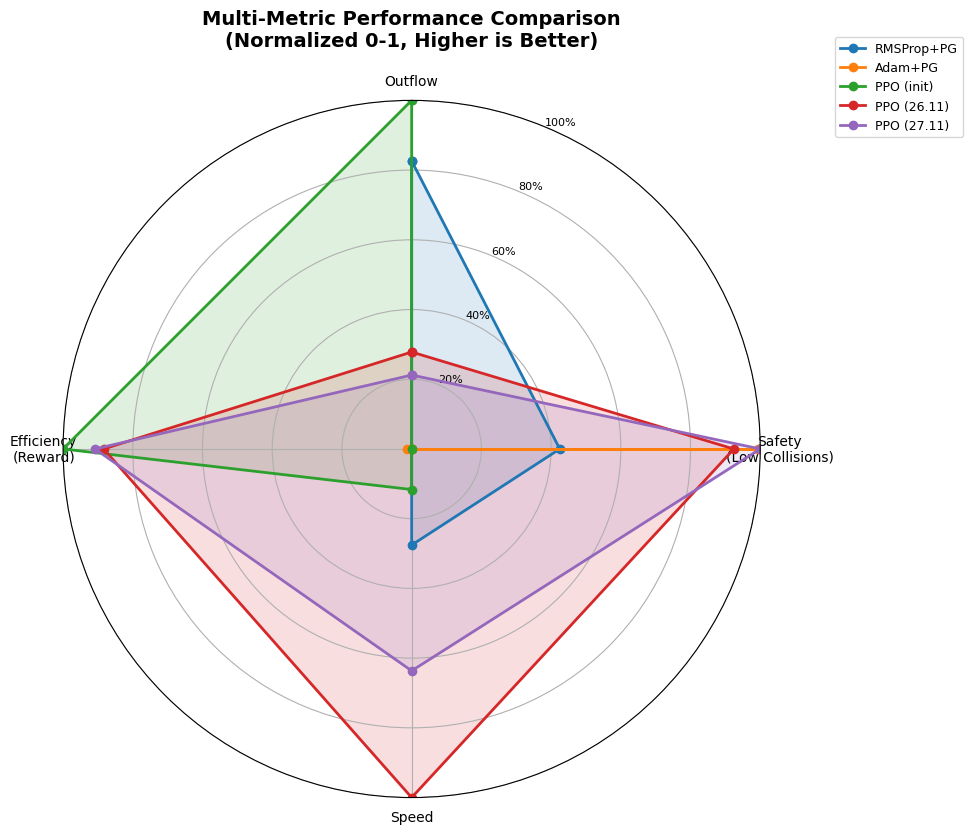

In [6]:
# VSCode.Cell - Multi-Metric Radar Chart

import numpy as np
import matplotlib.pyplot as plt

def create_radar_chart(data_dict, labels, title):
    """Create a radar chart comparing multiple metrics"""
    
    # Number of variables
    num_vars = len(labels)
    
    # Compute angle for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Complete the circle
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
    
    # Plot each experiment
    for exp_name, values in data_dict.items():
        values += values[:1]  # Complete the circle
        ax.plot(angles, values, 'o-', linewidth=2, label=exp_name)
        ax.fill(angles, values, alpha=0.15)
    
    # Fix axis to go in the right order
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    
    # Draw axis lines for each angle and label
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=10)
    
    # Set y-axis limits
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], size=8)
    
    # Add legend and title
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
    ax.set_title(title, size=14, weight='bold', pad=20)
    ax.grid(True)
    
    plt.tight_layout()
    return fig

# Normalize metrics (0-1 scale, higher is better)
def normalize_metric(values, inverse=False):
    """Normalize to 0-1 scale. If inverse=True, lower values are better."""
    min_val, max_val = min(values), max(values)
    if max_val == min_val:
        return [0.5] * len(values)
    
    if inverse:
        return [(max_val - v) / (max_val - min_val) for v in values]
    else:
        return [(v - min_val) / (max_val - min_val) for v in values]

# Prepare data for radar chart (top 5 experiments)
radar_data = {}
metric_labels = ['Outflow', 'Safety\n(Low Collisions)', 'Speed', 'Efficiency\n(Reward)']

for i, (df, name) in enumerate([
    (df1, 'RMSProp+PG'),
    (df2, 'Adam+PG'),
    (df3, 'PPO (init)'),
    (df4, 'PPO (26.11)'),
    (df5, 'PPO (27.11)')
], start=1):
    values = [
        df['outflow_hourly'].iloc[-10:].mean(),
        df['collisions'].iloc[-10:].mean(),
        df['speed'].iloc[-10:].mean() if 'speed' in df.columns else 0,
        df['global_reward_mean'].iloc[-10:].mean() if 'global_reward_mean' in df.columns 
        else df['reward_mean'].iloc[-10:].mean() if 'reward_mean' in df.columns else 0
    ]
    radar_data[name] = values

# Normalize each metric
all_values = list(radar_data.values())
normalized_data = {}

for i, metric in enumerate(metric_labels):
    metric_values = [v[i] for v in all_values]
    inverse = (i == 1)  # Collisions: lower is better
    normalized = normalize_metric(metric_values, inverse=inverse)
    
    for j, name in enumerate(radar_data.keys()):
        if name not in normalized_data:
            normalized_data[name] = []
        normalized_data[name].append(normalized[j])

# Create radar chart
fig = create_radar_chart(normalized_data, metric_labels, 
                         'Multi-Metric Performance Comparison\n(Normalized 0-1, Higher is Better)')
plt.show()  

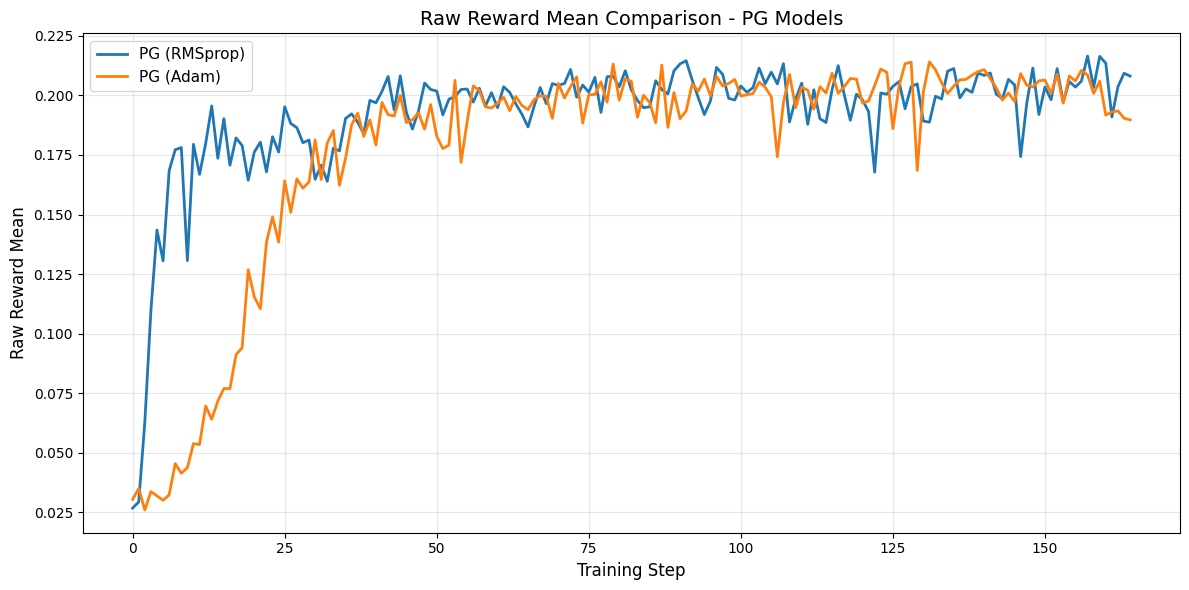

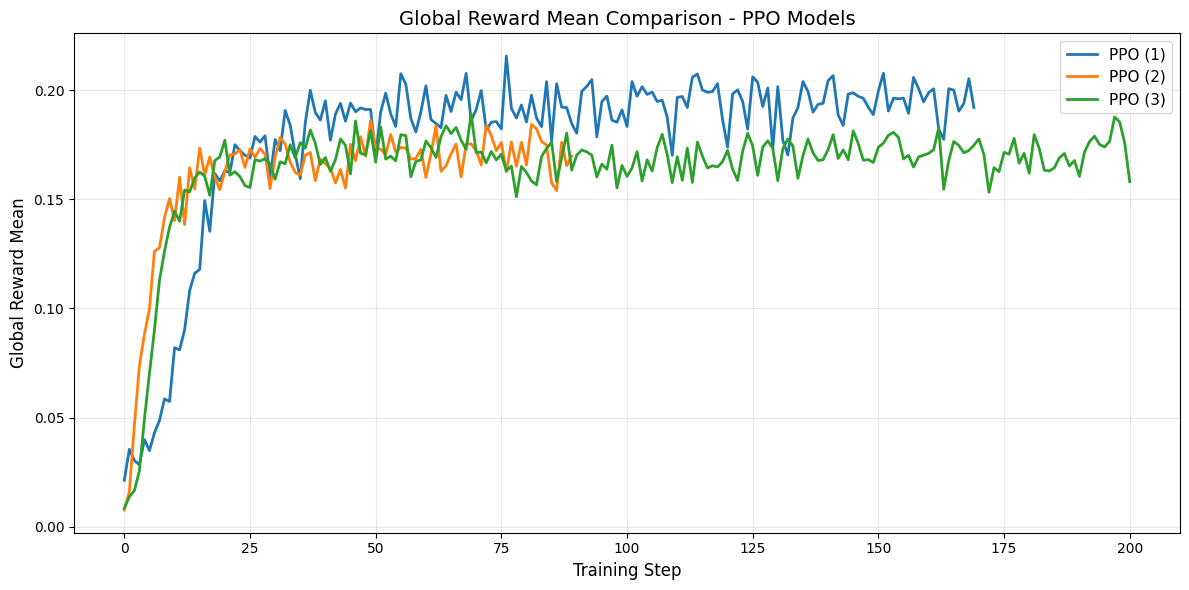

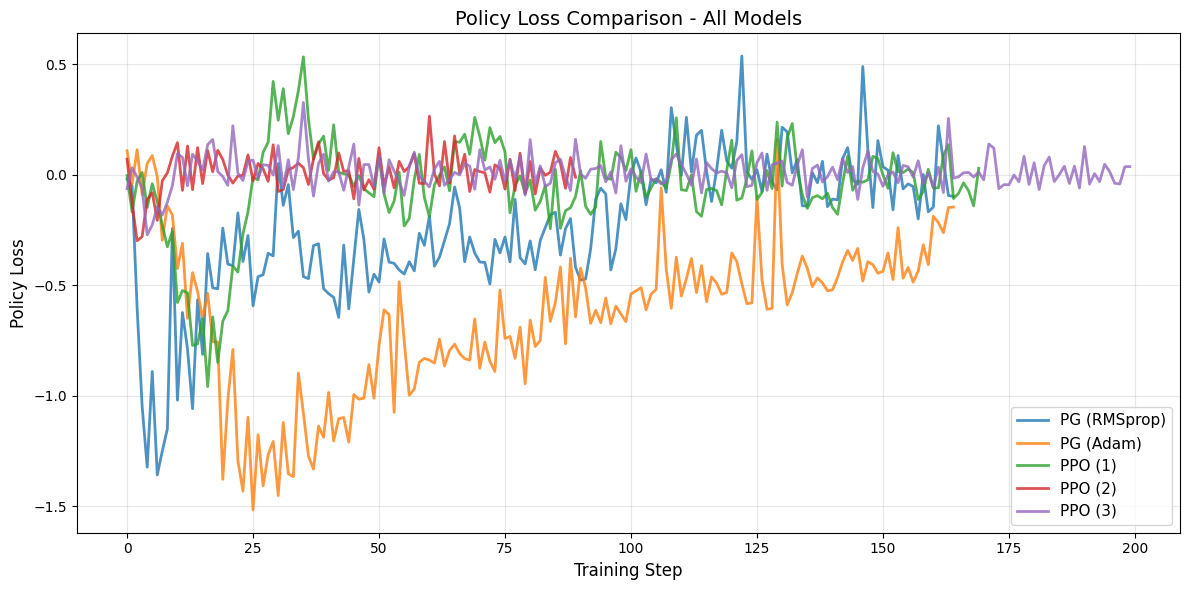

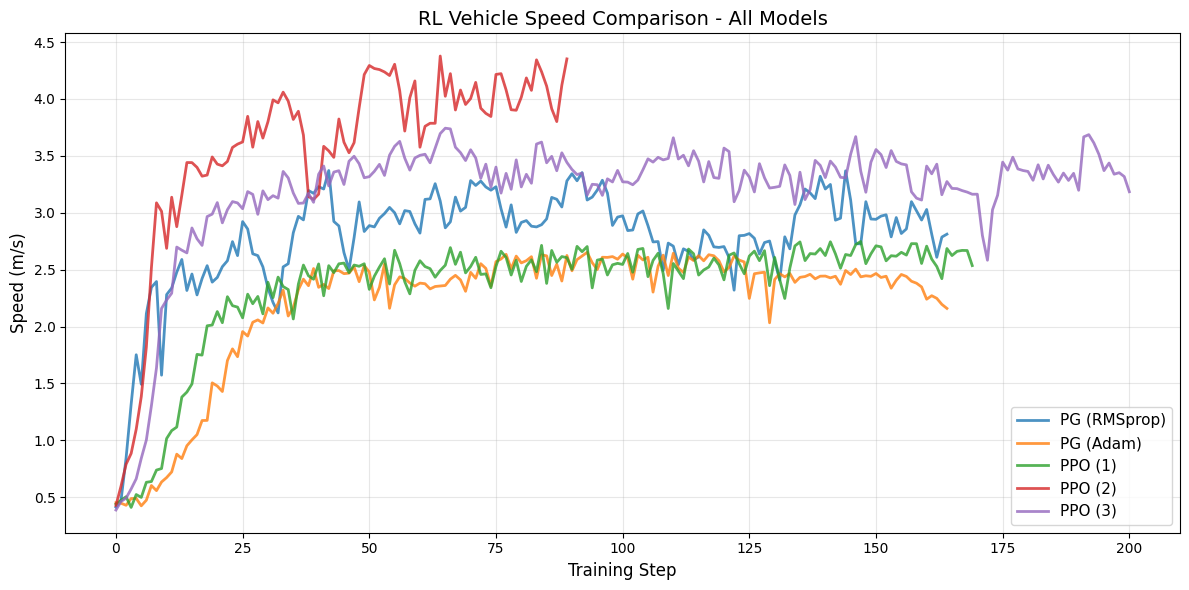

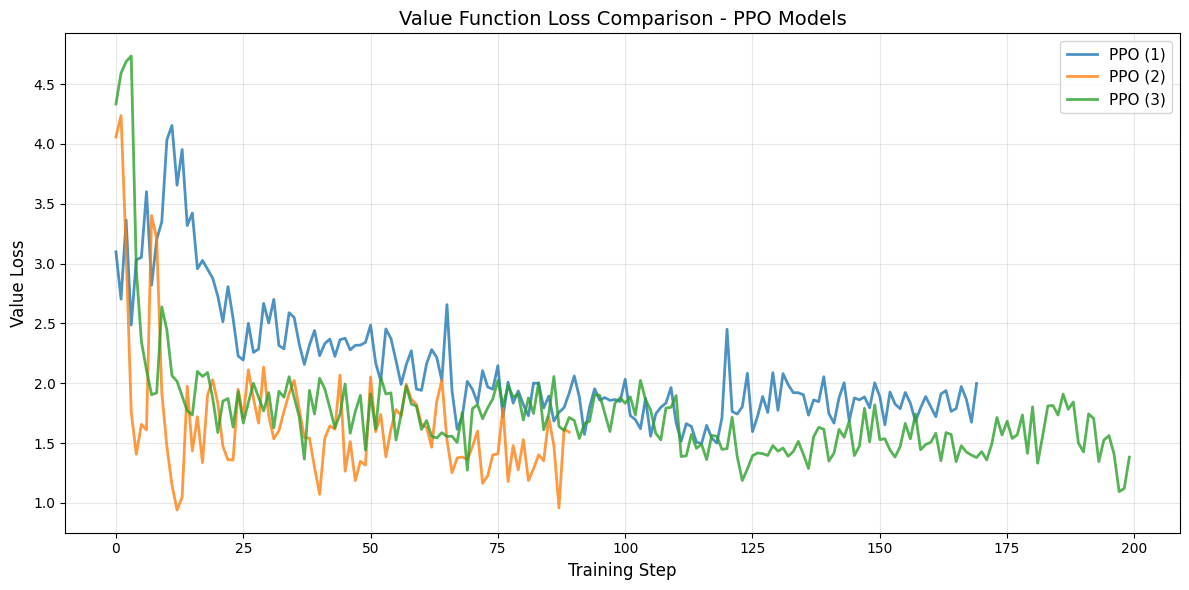

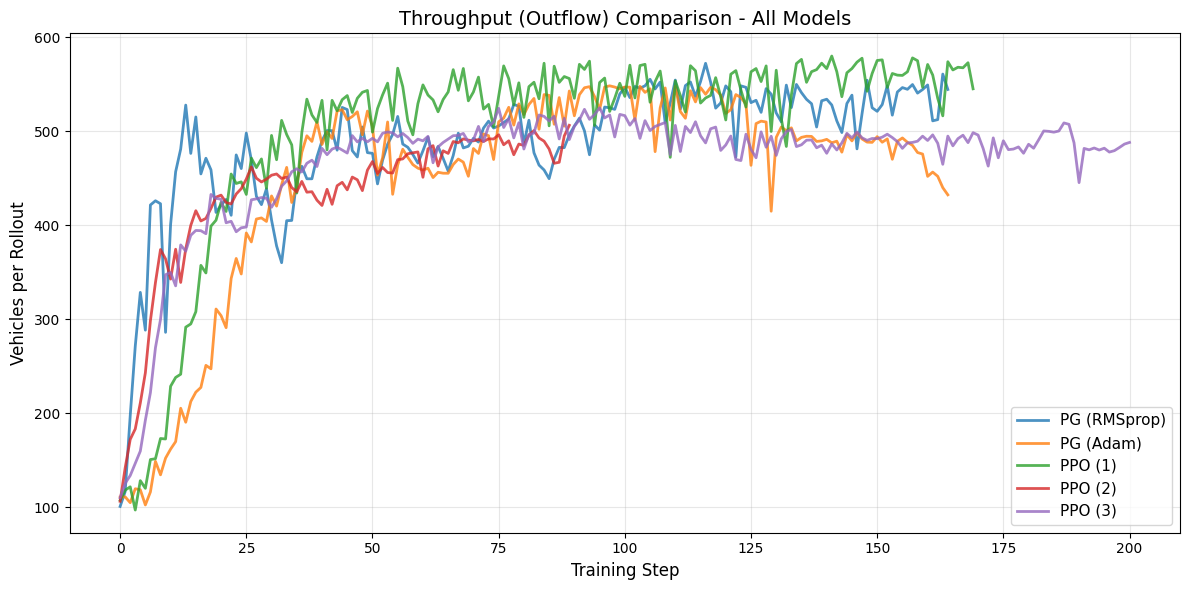


=== FINAL PERFORMANCE SUMMARY ===

PG (RMSprop):
  Raw Reward Mean (last 50): 0.2015
  Outflow (last 50): 532.42
  Speed RL (last 50): 2.879 m/s
  Collisions (last 50): 25.87

PG (Adam):
  Raw Reward Mean (last 50): 0.2029
  Outflow (last 50): 493.27
  Speed RL (last 50): 2.427 m/s
  Collisions (last 50): 17.49

PPO (1):
  Global Reward Mean (last 50): 0.1946
  Outflow (last 50): 557.26
  Speed RL (last 50): 2.612 m/s
  Collisions (last 50): 33.62

PPO (2):
  Global Reward Mean (last 50): 0.1710
  Outflow (last 50): 473.85
  Speed RL (last 50): 3.992 m/s
  Collisions (last 50): 13.18

PPO (3):
  Global Reward Mean (last 50): 0.1712
  Outflow (last 50): 487.22
  Speed RL (last 50): 3.312 m/s
  Collisions (last 50): 14.48



In [7]:
# 1. Compare Raw Reward Mean between 2 PG models
plt.figure(figsize=(12, 6))
plt.plot(df1['step'], df1['raw_reward_mean'], label='PG (RMSprop)', linewidth=2)
plt.plot(df2['step'], df2['raw_reward_mean'], label='PG (Adam)', linewidth=2)
plt.title('Raw Reward Mean Comparison - PG Models', fontsize=14)
plt.xlabel('Training Step', fontsize=12)
plt.ylabel('Raw Reward Mean', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Compare Global Reward Mean for PPO models
plt.figure(figsize=(12, 6))
plt.plot(df3['step'], df3['global_reward_mean'], label='PPO (1)', linewidth=2)
plt.plot(df4['step'], df4['global_reward_mean'], label='PPO (2)', linewidth=2)
plt.plot(df5['step'], df5['global_reward_mean'], label='PPO (3)', linewidth=2)
plt.title('Global Reward Mean Comparison - PPO Models', fontsize=14)
plt.xlabel('Training Step', fontsize=12)
plt.ylabel('Global Reward Mean', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Compare Policy Loss across all models
plt.figure(figsize=(12, 6))
plt.plot(df1['step'], df1['policy_loss'], label='PG (RMSprop)', linewidth=2, alpha=0.8)
plt.plot(df2['step'], df2['policy_loss'], label='PG (Adam)', linewidth=2, alpha=0.8)
plt.plot(df3['step'], df3['policy_loss'], label='PPO (1)', linewidth=2, alpha=0.8)
plt.plot(df4['step'], df4['policy_loss'], label='PPO (2)', linewidth=2, alpha=0.8)
plt.plot(df5['step'], df5['policy_loss'], label='PPO (3)', linewidth=2, alpha=0.8)
plt.title('Policy Loss Comparison - All Models', fontsize=14)
plt.xlabel('Training Step', fontsize=12)
plt.ylabel('Policy Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Compare RL Vehicle Speed across all models
plt.figure(figsize=(12, 6))
plt.plot(df1['step'], df1['speed_rl'], label='PG (RMSprop)', linewidth=2, alpha=0.8)
plt.plot(df2['step'], df2['speed_rl'], label='PG (Adam)', linewidth=2, alpha=0.8)
plt.plot(df3['step'], df3['speed_rl'], label='PPO (1)', linewidth=2, alpha=0.8)
plt.plot(df4['step'], df4['speed_rl'], label='PPO (2)', linewidth=2, alpha=0.8)
plt.plot(df5['step'], df5['speed_rl'], label='PPO (3)', linewidth=2, alpha=0.8)
plt.title('RL Vehicle Speed Comparison - All Models', fontsize=14)
plt.xlabel('Training Step', fontsize=12)
plt.ylabel('Speed (m/s)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Compare Value Function Loss for PPO models only
plt.figure(figsize=(12, 6))
plt.plot(df3['step'], df3['value_loss'], label='PPO (1)', linewidth=2, alpha=0.8)
plt.plot(df4['step'], df4['value_loss'], label='PPO (2)', linewidth=2, alpha=0.8)
plt.plot(df5['step'], df5['value_loss'], label='PPO (3)', linewidth=2, alpha=0.8)
plt.title('Value Function Loss Comparison - PPO Models', fontsize=14)
plt.xlabel('Training Step', fontsize=12)
plt.ylabel('Value Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Bonus: Compare Throughput (Outflow) across all models
plt.figure(figsize=(12, 6))
plt.plot(df1['step'], df1['outflow'], label='PG (RMSprop)', linewidth=2, alpha=0.8)
plt.plot(df2['step'], df2['outflow'], label='PG (Adam)', linewidth=2, alpha=0.8)
plt.plot(df3['step'], df3['outflow'], label='PPO (1)', linewidth=2, alpha=0.8)
plt.plot(df4['step'], df4['outflow'], label='PPO (2)', linewidth=2, alpha=0.8)
plt.plot(df5['step'], df5['outflow'], label='PPO (3)', linewidth=2, alpha=0.8)
plt.title('Throughput (Outflow) Comparison - All Models', fontsize=14)
plt.xlabel('Training Step', fontsize=12)
plt.ylabel('Vehicles per Rollout', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Print summary statistics for final performance
print("\n=== FINAL PERFORMANCE SUMMARY ===\n")

models = {
    'PG (RMSprop)': df1,
    'PG (Adam)': df2,
    'PPO (1)': df3,
    'PPO (2)': df4,
    'PPO (3)': df5
}

for name, df in models.items():
    last_50_steps = df.tail(50)
    print(f"{name}:")
    if 'raw_reward_mean' in df.columns:
        print(f"  Raw Reward Mean (last 50): {last_50_steps['raw_reward_mean'].mean():.4f}")
    if 'global_reward_mean' in df.columns:
        print(f"  Global Reward Mean (last 50): {last_50_steps['global_reward_mean'].mean():.4f}")
    print(f"  Outflow (last 50): {last_50_steps['outflow'].mean():.2f}")
    print(f"  Speed RL (last 50): {last_50_steps['speed_rl'].mean():.3f} m/s")
    print(f"  Collisions (last 50): {last_50_steps['collisions'].mean():.2f}")
    print()

✓ Loaded baseline comparison files:
  Fixed-time 25(new): 3 steps
  Signal 25 (old): 3 steps


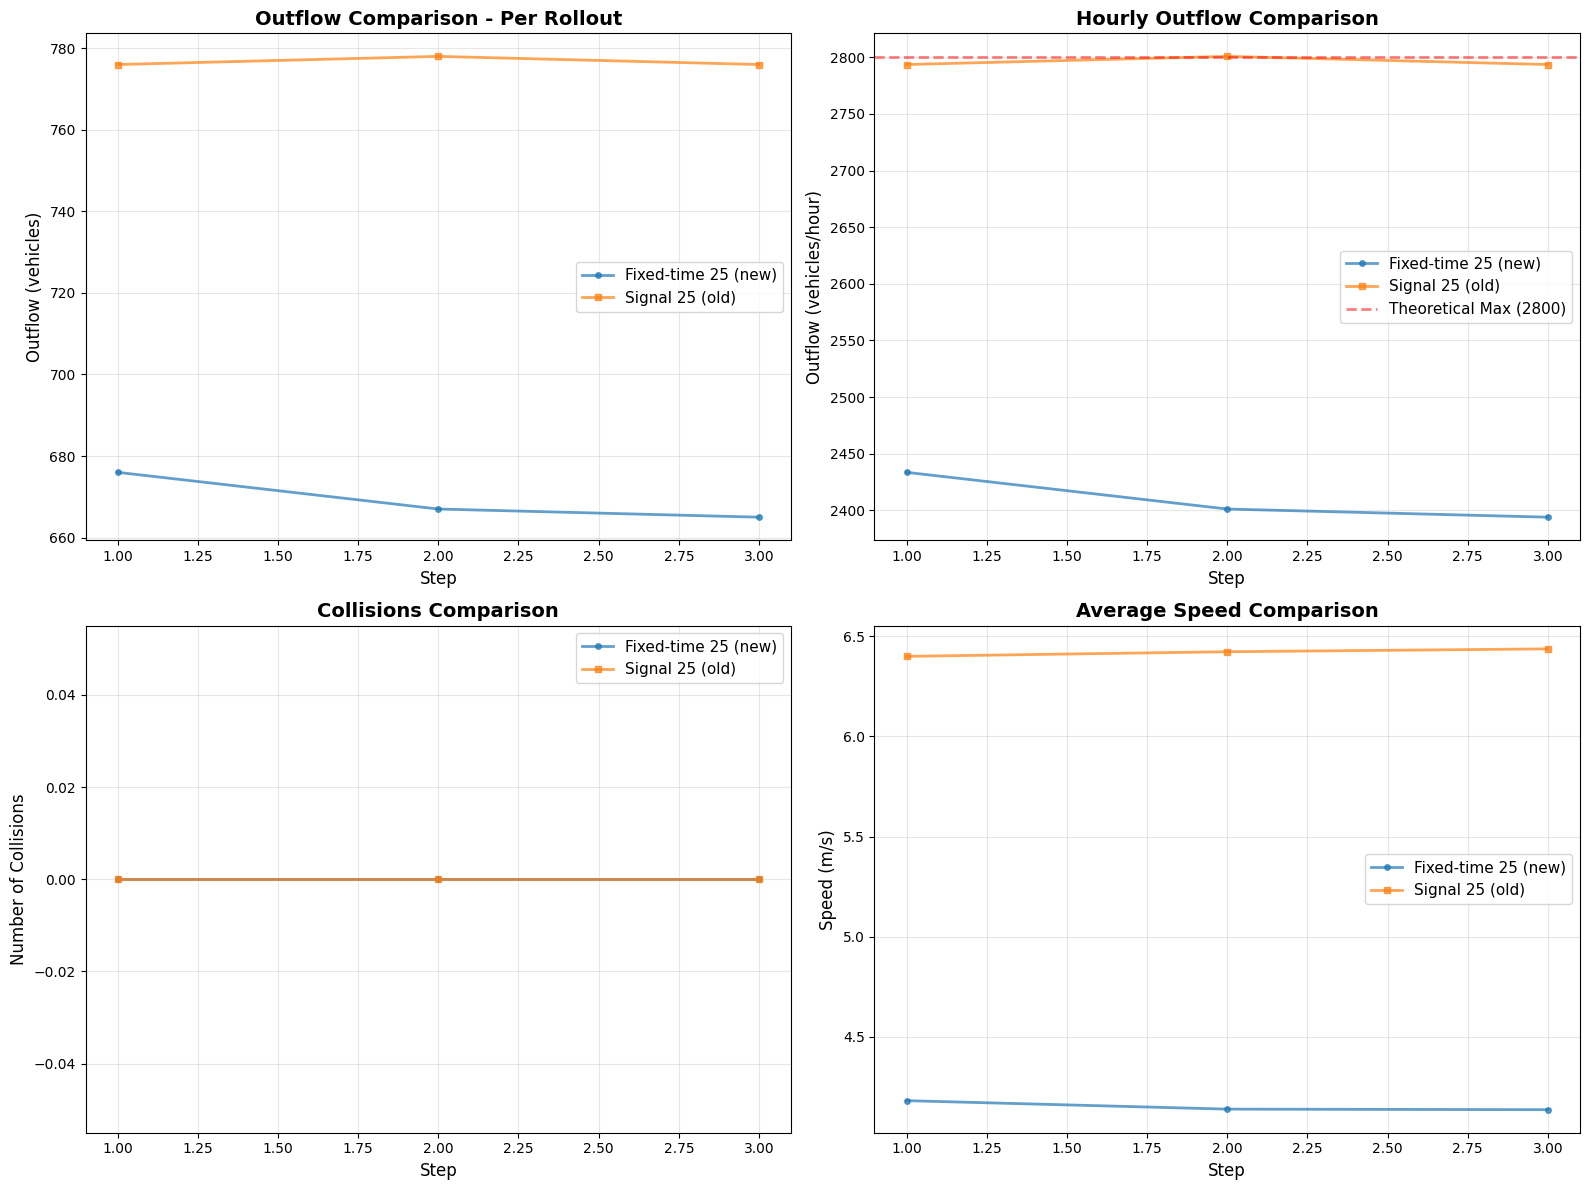


STATISTICAL COMPARISON

1. OUTFLOW STATISTICS:
--------------------------------------------------------------------------------
Metric                         Fixed-time (no LR)   Signal 25 (with LR) 
--------------------------------------------------------------------------------
Outflow (mean)                 669.33               776.67              
Outflow (std)                  5.86                 1.15                
Outflow (min)                  665.00               776.00              
Outflow (max)                  676.00               778.00              
Hourly Outflow (mean)          2409.60              2796.00             
Hourly Outflow (std)           21.09                4.16                

2. SAFETY & EFFICIENCY:
--------------------------------------------------------------------------------
Collisions (total)             0.00                 0.00                
Collisions (mean)              0.00                 0.00                
Average Speed (m/s)        

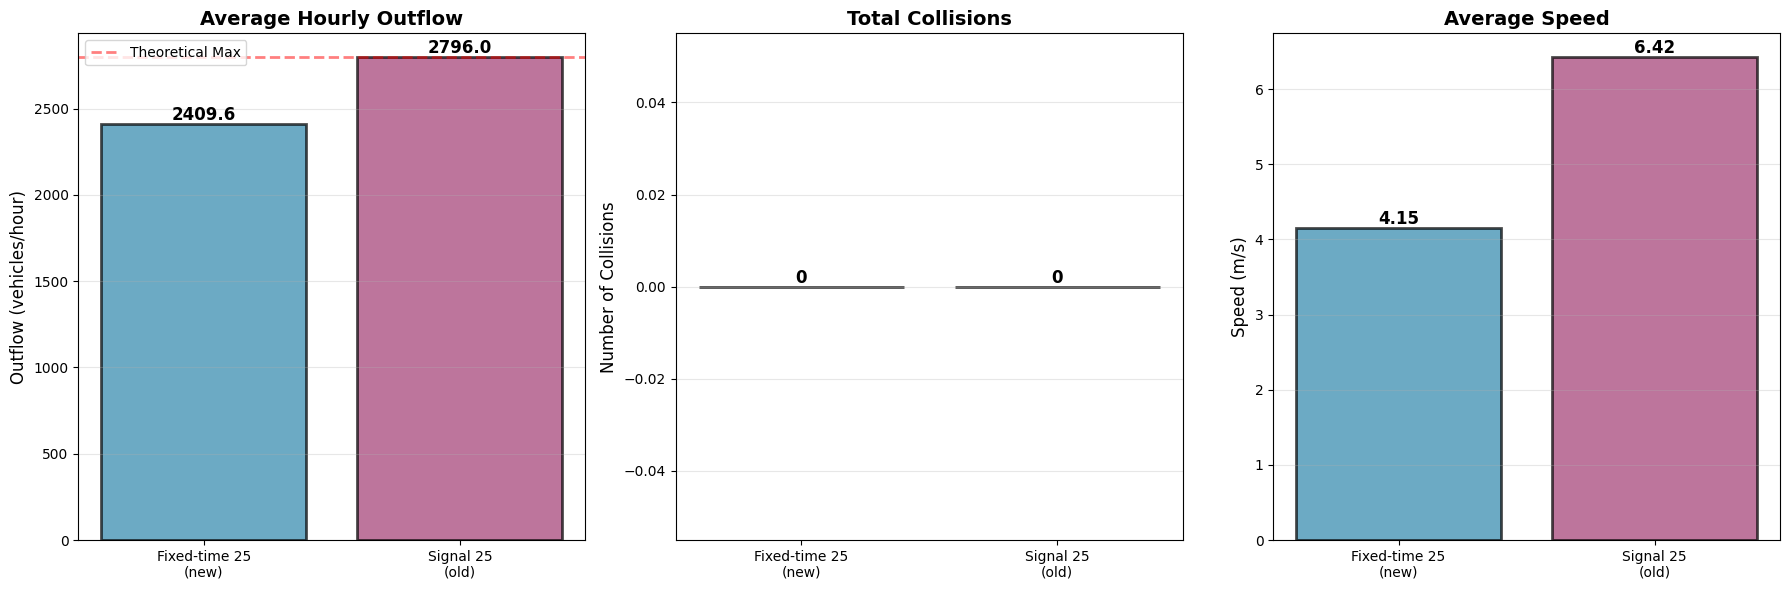

In [12]:
# VSCode.Cell - Compare Baseline Outflows

# Load the two baseline CSV files
df_fixedtime = pd.read_csv('results/fourway_1x1_left_right_turn_baselines/eval_results/skip500_fixedtime_yellow0_no_lr_flow700x700.csv')
df_signal25 = pd.read_csv('results/fourway_1x1_baselines/eval_results/skip500_signal25_yellow0_flow700x700.csv')

print("✓ Loaded baseline comparison files:")
print(f"  Fixed-time 25(new): {len(df_fixedtime)} steps")
print(f"  Signal 25 (old): {len(df_signal25)} steps")

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Plot 1: Outflow per Rollout ---
ax1 = axes[0, 0]
ax1.plot(df_fixedtime['step'], df_fixedtime['outflow'], 
         label='Fixed-time 25 (new)', linewidth=2, marker='o', markersize=4, alpha=0.7)
ax1.plot(df_signal25['step'], df_signal25['outflow'], 
         label='Signal 25 (old)', linewidth=2, marker='s', markersize=4, alpha=0.7)
ax1.set_title('Outflow Comparison - Per Rollout', fontsize=14, fontweight='bold')
ax1.set_xlabel('Step', fontsize=12)
ax1.set_ylabel('Outflow (vehicles)', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Hourly Outflow ---
ax2 = axes[0, 1]
ax2.plot(df_fixedtime['step'], df_fixedtime['outflow_hourly'], 
         label='Fixed-time 25 (new)', linewidth=2, marker='o', markersize=4, alpha=0.7)
ax2.plot(df_signal25['step'], df_signal25['outflow_hourly'], 
         label='Signal 25 (old)', linewidth=2, marker='s', markersize=4, alpha=0.7)
ax2.axhline(y=2800, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Theoretical Max (2800)')
ax2.set_title('Hourly Outflow Comparison', fontsize=14, fontweight='bold')
ax2.set_xlabel('Step', fontsize=12)
ax2.set_ylabel('Outflow (vehicles/hour)', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# --- Plot 3: Collisions ---
ax3 = axes[1, 0]
ax3.plot(df_fixedtime['step'], df_fixedtime['collisions'], 
         label='Fixed-time 25 (new)', linewidth=2, marker='o', markersize=4, alpha=0.7)
ax3.plot(df_signal25['step'], df_signal25['collisions'], 
         label='Signal 25 (old)', linewidth=2, marker='s', markersize=4, alpha=0.7)
ax3.set_title('Collisions Comparison', fontsize=14, fontweight='bold')
ax3.set_xlabel('Step', fontsize=12)
ax3.set_ylabel('Number of Collisions', fontsize=12)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# --- Plot 4: Average Speed ---
ax4 = axes[1, 1]
ax4.plot(df_fixedtime['step'], df_fixedtime['speed'], 
         label='Fixed-time 25 (new)', linewidth=2, marker='o', markersize=4, alpha=0.7)
ax4.plot(df_signal25['step'], df_signal25['speed'], 
         label='Signal 25 (old)', linewidth=2, marker='s', markersize=4, alpha=0.7)
ax4.set_title('Average Speed Comparison', fontsize=14, fontweight='bold')
ax4.set_xlabel('Step', fontsize=12)
ax4.set_ylabel('Speed (m/s)', fontsize=12)
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Statistical Comparison ---
print("\n" + "="*80)
print("STATISTICAL COMPARISON")
print("="*80)

print("\n1. OUTFLOW STATISTICS:")
print("-" * 80)
print(f"{'Metric':<30} {'Fixed-time (no LR)':<20} {'Signal 25 (with LR)':<20}")
print("-" * 80)

metrics = {
    'Outflow (mean)': ('outflow', 'mean'),
    'Outflow (std)': ('outflow', 'std'),
    'Outflow (min)': ('outflow', 'min'),
    'Outflow (max)': ('outflow', 'max'),
    'Hourly Outflow (mean)': ('outflow_hourly', 'mean'),
    'Hourly Outflow (std)': ('outflow_hourly', 'std'),
}

for metric_name, (col, stat) in metrics.items():
    val_fixedtime = getattr(df_fixedtime[col], stat)()
    val_signal25 = getattr(df_signal25[col], stat)()
    print(f"{metric_name:<30} {val_fixedtime:<20.2f} {val_signal25:<20.2f}")

print("\n2. SAFETY & EFFICIENCY:")
print("-" * 80)

other_metrics = {
    'Collisions (total)': ('collisions', 'sum'),
    'Collisions (mean)': ('collisions', 'mean'),
    'Average Speed (m/s)': ('speed', 'mean'),
    'Speed Std Dev': ('speed', 'std'),
}

for metric_name, (col, stat) in other_metrics.items():
    val_fixedtime = getattr(df_fixedtime[col], stat)()
    val_signal25 = getattr(df_signal25[col], stat)()
    print(f"{metric_name:<30} {val_fixedtime:<20.2f} {val_signal25:<20.2f}")

print("\n3. THROUGHPUT COMPARISON:")
print("-" * 80)
avg_outflow_fixedtime = df_fixedtime['outflow_hourly'].mean()
avg_outflow_signal25 = df_signal25['outflow_hourly'].mean()
diff_abs = avg_outflow_signal25 - avg_outflow_fixedtime
diff_pct = (diff_abs / avg_outflow_fixedtime) * 100

print(f"Fixed-time 25 (new): {avg_outflow_fixedtime:.2f} veh/hr")
print(f"Signal 25 (old): {avg_outflow_signal25:.2f} veh/hr")
print(f"Difference: {diff_abs:.2f} veh/hr ({diff_pct:+.2f}%)")

if diff_abs > 0:
    print(f"✓ Signal 25 has {diff_pct:.2f}% HIGHER throughput")
else:
    print(f"✗ Signal 25 has {abs(diff_pct):.2f}% LOWER throughput")

print("\n4. EFFICIENCY METRICS:")
print("-" * 80)
# Throughput per unit time
efficiency_fixedtime = avg_outflow_fixedtime / 2800 * 100  # % of theoretical max
efficiency_signal25 = avg_outflow_signal25 / 2800 * 100

print(f"Fixed-time efficiency: {efficiency_fixedtime:.1f}% of theoretical max")
print(f"Signal 25 efficiency: {efficiency_signal25:.1f}% of theoretical max")

print("="*80)

# --- Bar Chart Comparison ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Average Outflow
ax1 = axes[0]
categories = ['Fixed-time 25\n(new)', 'Signal 25\n(old)']
outflow_values = [avg_outflow_fixedtime, avg_outflow_signal25]
colors = ['#2E86AB', '#A23B72']
bars = ax1.bar(categories, outflow_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# Add value labels
for bar, val in zip(bars, outflow_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax1.axhline(y=2800, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Theoretical Max')
ax1.set_title('Average Hourly Outflow', fontsize=14, fontweight='bold')
ax1.set_ylabel('Outflow (vehicles/hour)', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Total Collisions
ax2 = axes[1]
collision_values = [df_fixedtime['collisions'].sum(), df_signal25['collisions'].sum()]
bars = ax2.bar(categories, collision_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

for bar, val in zip(bars, collision_values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.0f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax2.set_title('Total Collisions', fontsize=14, fontweight='bold')
ax2.set_ylabel('Number of Collisions', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Average Speed
ax3 = axes[2]
speed_values = [df_fixedtime['speed'].mean(), df_signal25['speed'].mean()]
bars = ax3.bar(categories, speed_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

for bar, val in zip(bars, speed_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax3.set_title('Average Speed', fontsize=14, fontweight='bold')
ax3.set_ylabel('Speed (m/s)', fontsize=12)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# --- Create Comparison Summary DataFrame ---
summary_data = {
    'Metric': [
        'Avg Hourly Outflow (veh/hr)',
        'Efficiency (% of max)',
        'Total Collisions',
        'Avg Speed (m/s)',
        'Outflow Std Dev',
    ],
    'Fixed-time (no LR turns)': [
        avg_outflow_fixedtime,
        efficiency_fixedtime,
        df_fixedtime['collisions'].sum(),
        df_fixedtime['speed'].mean(),
        df_fixedtime['outflow_hourly'].std(),
    ],
    'Signal 25 (with LR turns)': [
        avg_outflow_signal25,
        efficiency_signal25,
        df_signal25['collisions'].sum(),
        df_signal25['speed'].mean(),
        df_signal25['outflow_hourly'].std(),
    ]
}

# summary_df = pd.DataFrame(summary_data)
# summary_df['Difference'] = summary_df['Signal 25 (old)'] - summary_df['Fixed-time (new)']
# summary_df['% Change'] = (summary_df['Difference'] / summary_df['Fixed-time (new)']) * 100

# print("\n" + "="*100)
# print("SUMMARY TABLE")
# print("="*100)
# print(summary_df.to_string(index=False, float_format=lambda x: f'{x:.2f}'))
# print("="*100)
